In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import KID_S21 as S21
import pandas as pd
import pickle
from copy import copy
import glob 

import matplotlibcolors
plt.style.use('matplotlibrc')

%matplotlib widget

In [2]:
# # WILBERT
# dir  = r"C:\Users\wilbertr\ownCloud2\PhD\PhD\PythonProjects\sonnet\LT402 Design/"
# chip = 'LT402_32x32_4-8GHz'
# path = dir + chip + '/'
# with open('LT402chip6_master.pkl', 'rb') as f:
#     master = pickle.load(f)
# kid_id_board = np.load( path + chip + '_id.npy')
# f0_mapped = master['measured']['f0']


In [3]:
# # # WILBERT
# # dir = r'Z:\KIDonSun\experiments\Entropy ADR\LT402chip6_BF_20250919\S21\Power/'
# # df = S21.loop_over_S21_files(dir, kid=0, pread=116)
# # display(df)
# # with open('LT402chip6_Qs.pkl', 'wb') as f:
# #     pickle.dump(df, f)

# with open('LT402chip6_Qs.pkl', 'rb') as f:
#     df = pickle.load(f)
# display(df)

/Users/roland/Library/Mobile Documents/com~apple~CloudDocs/TU/TU 2025—2026/cc/code/S21vPdata/S21 fitting code met khalilswenson net 2/KID_S21.py:54: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_results = pd.concat([df_results, new_entry], ignore_index=True)
/Users/roland/Library/Mobile Documents/com~apple~CloudDocs/TU/TU 2025—2026/cc/code/S21vPdata/S21 fitting code met khalilswenson net 2/KID_S21.py:54: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_results = pd.concat([df_results, new_ent

,KID,Power,Temperature,f0,f0_std,Ql,Ql_std,Qc,Qc_std,Qi,Qi_std,Pint,redchisqr,phi,a_nonlin,a_nonlin_std,dw,dw_std,a,a_std,b,b_std
0,530,-102.000000,0.000000,6.243787,0.000000,54303.977056,48.687512,58459.391080,111.565671,763961.764883,17270.502044,-59.943409,0.000008,-0.126616,0.61,0.001354,-7.32e-06,0.000000,1.024941,0.000113,16.042196,0.175374
1,530,-104.000000,0.000000,6.243788,0.000000,55187.393683,39.003656,59130.512139,79.976945,827583.266467,14505.633536,-61.852817,0.000004,-0.128654,0.40,0.001110,-7.32e-06,0.000000,1.024684,0.000084,16.478080,0.129902
2,530,-106.000000,0.000000,6.243788,0.000000,55093.385137,49.710066,58683.892441,96.324708,900456.123295,21190.925694,-63.834699,0.000007,-0.128437,0.26,0.001417,-7.32e-06,0.000000,1.025040,0.000105,16.469459,0.161023
3,530,-108.000000,0.000000,6.243787,0.000000,55692.580692,56.790074,60281.464979,95.717125,731600.568313,13424.028304,-65.857390,0.000008,-0.129818,0.15,0.001588,-7.32e-06,0.000000,1.023970,0.000113,15.921711,0.173079
4,530,-110.000000,0.000000,6.243786,0.000000,55057.347528,67.822842,58896.182862,117.089236,844700.885981,22862.350191,-67.856065,0.000011,-0.128354,0.11,0.001902,-7.32e-06,0.000000,1.024245,0.000138,15.916884,0.210299
5,530,-112.000000,0.000000,6.243785,0.000000,55630.578825,75.292350,60238.997904,121.253794,727175.689571,16891.532532,-69.864005,0.000013,-0.129675,0.08,0.002080,-7.32e-06,0.000000,1.023403,0.000148,15.755520,0.225051
6,530,-114.000000,0.000000,6.243783,0.000000,55243.480946,88.888275,60504.649579,135.034453,635312.739333,14328.164970,-71.943766,0.000018,-0.128783,0.04,0.002450,-7.32e-06,0.000000,1.023450,0.000173,16.217396,0.262741
7,530,-116.000000,0.000000,6.243782,0.000000,54049.303643,110.038244,59166.925666,164.725611,624886.151549,17704.721960,-74.036487,0.000029,-0.126029,0.02,0.003072,-7.32e-06,0.000000,1.024296,0.000221,16.805854,0.333646
8,530,-118.000000,0.000000,6.243784,0.000000,54917.102667,144.363845,60314.112790,215.731301,613724.311965,21535.499613,-75.981536,0.000047,-0.128031,0.03,0.003986,-7.32e-06,0.000000,1.023720,0.000282,16.017964,0.427532
9,530,-120.000000,0.000000,6.243782,0.000000,54649.888343,162.960480,60187.887825,238.866910,593943.961179,22461.049423,-78.014804,0.000060,-0.127414,0.00,0.004495,-7.32e-06,0.000000,1.023505,0.000319,16.226577,0.481804


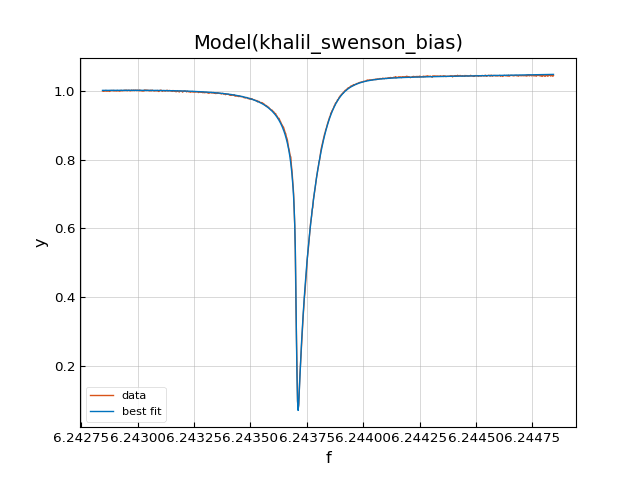

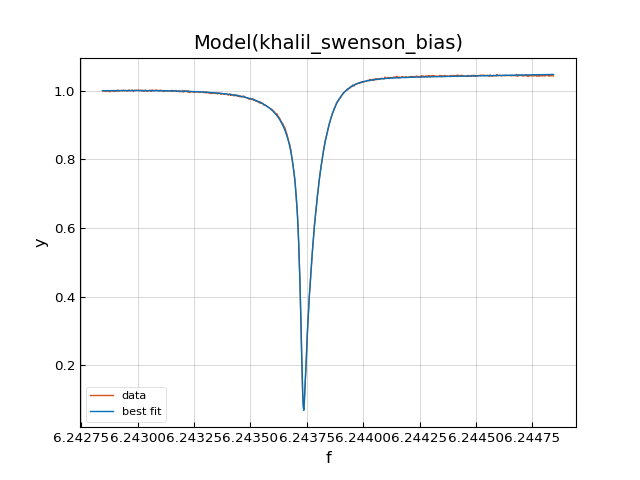

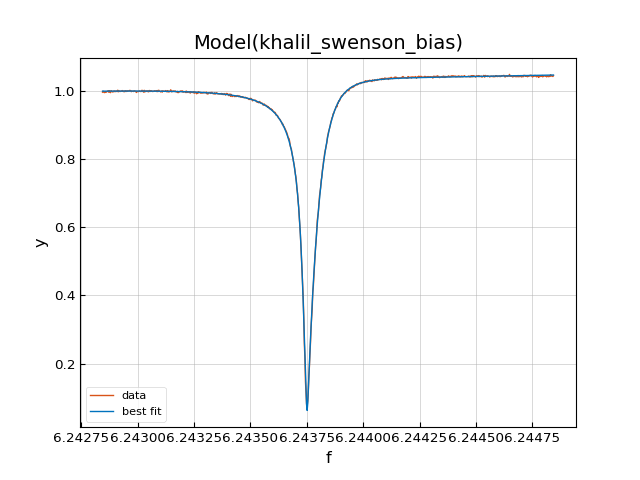

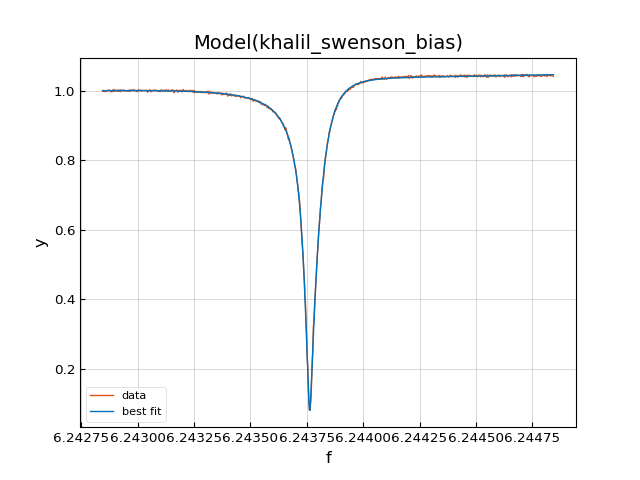

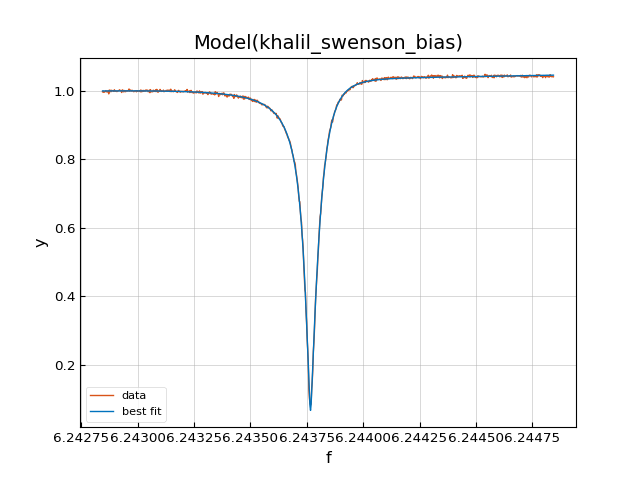

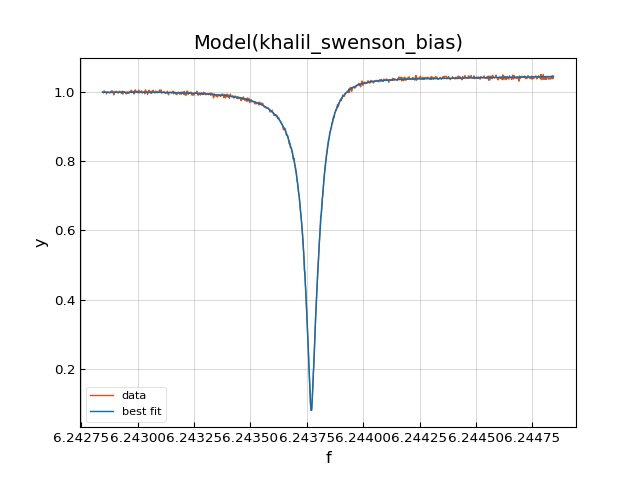

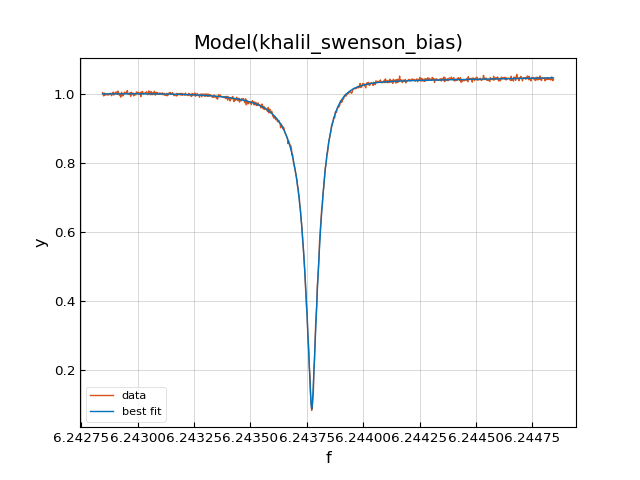

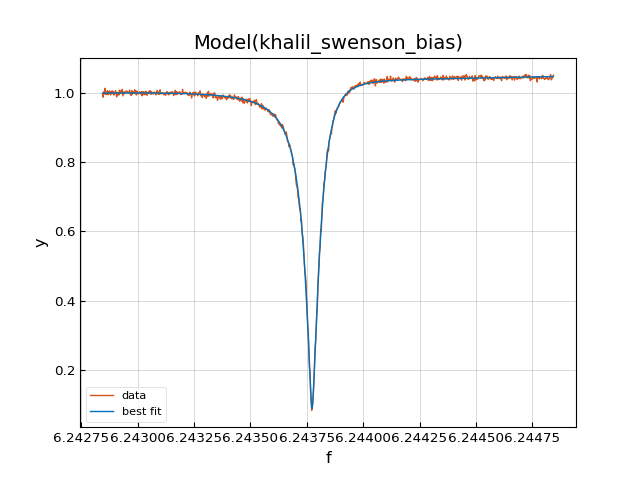

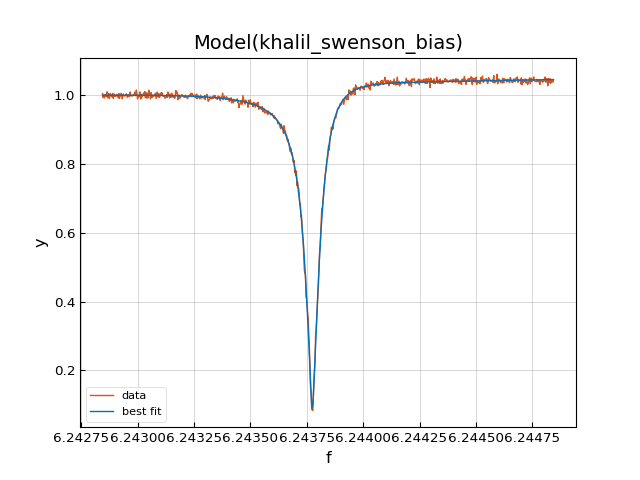

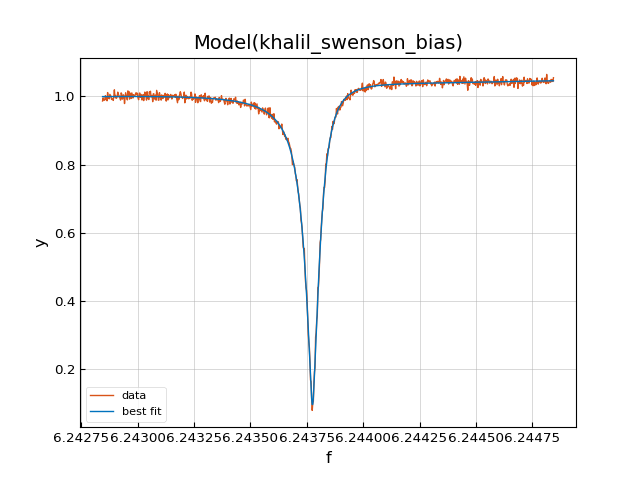

In [4]:
# chip_name = 'LT192chip5'
# chip_name = 'LT295chip3'
# chip_name = 'LT361chip4'
# chip_name = 'LT361chip4_trimmed'
# chip_name = 'LT402chip5'
chip_name = 'LT402chip6'
# chip_name = 'LT402chip6_trimmed'
# chip_name = 'LT361chip7'
# chip_name = 'LT361chip8'

kid_nr = 530
P_read = None # *-1dBm

T_suffix = "" if chip_name != 'LT402chip6_trimmed' else "_25mK"
dir = f'/Users/roland/Documents/cccode/code/S21vPdata/{chip_name}/S21{T_suffix}/Power/'



# KhalilSwenson op alle powers
# df = S21.loop_over_S21_files(dir, kid=kid_nr, pread=P_read, plot=True, model='khalilswenson', method='least_squares') # swenson does not work well without 'least_squares' method.


# Khalil magspace op alle powers
# df = S21.loop_over_S21_files(dir, kid=kid_nr, pread=P_read, plot=True)


# Khalil magspace op laagste power en dan met die dw KhalilSwenson op alle powers
df = S21.loop_over_S21_files(dir, kid=kid_nr, pread=112 if chip_name == 'LT192chip5' else 120, plot=False, model='', method='')
dw120 = df['dw'][0]
df = S21.loop_over_S21_files(dir, kid=kid_nr, pread=P_read, plot=True, model='khalilswensonbias', method='least_squares', dw_low_power=dw120) # swenson does not work well without 'least_squares' method.



display(df.style.format({'a_nonlin': '{:.2f}',
                         'dw': '{:.2e}'}))

# with open('LT402chip6_Qs.pkl', 'wb') as f:
#     pickle.dump(df, f)

# with open('LT402chip6_Qs.pkl', 'rb') as f:
#     df = pickle.load(f)
# display(df)

In [5]:
raise SystemExit

SystemExit: 

/Users/roland/delphyne/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


filtered: 729 / 997


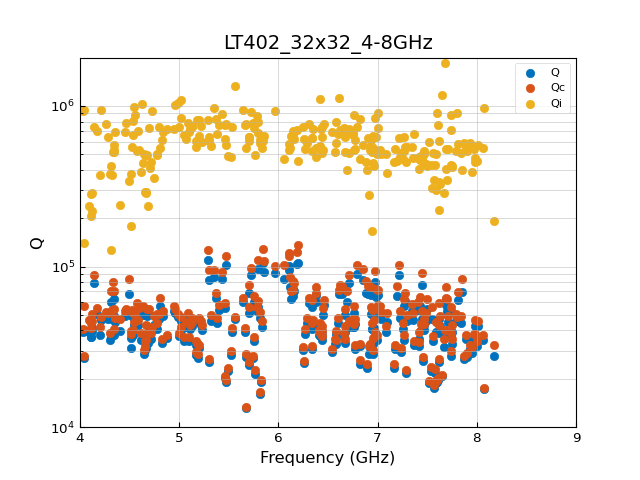

In [ ]:
f0_Q = df['f0']
Ql = df['Ql']
Qc = df['Qc']
Qi = df['Qi']
phi = df['phi']

min_df = 0.002
df0s = np.asarray(f0_Q)[1:] - np.asarray(f0_Q)[:-1]
too_close = df0s < min_df
too_close_mask = np.hstack((False, too_close)) + np.hstack((too_close, False))

Qi_mask = (Qi > 1e5) & (Qi < 2e6)
Qc_mask = Qc < 1.5e5
mask = Qi_mask & Qc_mask & ~too_close_mask
# mask = np.ones(len(df), dtype=bool)  # all
df_filtered = copy(df)
df_filtered[~mask] = np.nan
f0_Q = df_filtered['f0']
Ql = df_filtered['Ql']
Qc = df_filtered['Qc']
Qi = df_filtered['Qi']
phi = df_filtered['phi']
print('filtered:', np.sum(mask==False), '/', len(mask))
fig, ax = plt.subplots()
ax.set_title(chip)
ax.set_yscale('log')
ax.scatter(f0_Q, Ql, label='Q')
ax.scatter(f0_Q, Qc, label='Qc')
ax.scatter(f0_Q, Qi, label='Qi')
ax.set_xlim(4,9)
ax.set_xlabel('Frequency (GHz)')    
ax.set_ylim(1e4,2e6)
ax.set_ylabel('Q')
ax.legend()

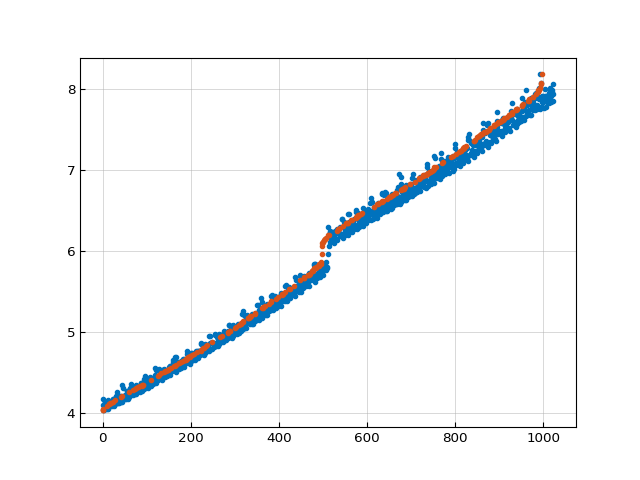

In [ ]:
fig, ax = plt.subplots()
ax.plot(f0_mapped, '.')
ax.plot(f0_Q, '.')

In [ ]:
nr = len(f0_mapped)
f0_dark = f0_Q
idxs = np.empty(nr)
idxs[:] = np.nan
for id, f0 in enumerate(f0_mapped):
    if ~np.isnan(f0):
        closest =  np.nanargmin(np.abs(f0 - f0_dark))
        if ~np.isnan(f0_dark[closest]):
            tone = f0_dark[closest]
            if closest in idxs:
                idx_location = np.where(idxs == closest)[0]
                if len(idx_location) == 1:
                    prev_id = idx_location[0]
                    prev_f0 = f0_mapped[prev_id]
                    curr_diff = np.abs(f0 - tone)
                    prev_diff = np.abs(prev_f0 - tone)
                    if curr_diff < prev_diff:
                        idxs[prev_id] = np.nan
                    else:
                        closest = np.nan
                else:
                    print('more than one match')
                    closest = np.nan
            else:
                pass
        else:
            closest = np.nan
    else:
        closest = np.nan
    idxs[id] = closest
print(idxs)


[ nan   0.  nan ... 967.  nan 994.]


In [ ]:
df_sorted = pd.DataFrame(np.nan, index=np.arange(nr), columns=df_filtered.columns)
for i, idx in enumerate(idxs):
    if ~np.isnan(idx):
        df_sorted.iloc[i] = df_filtered.iloc[int(idx)]
    else:
        pass

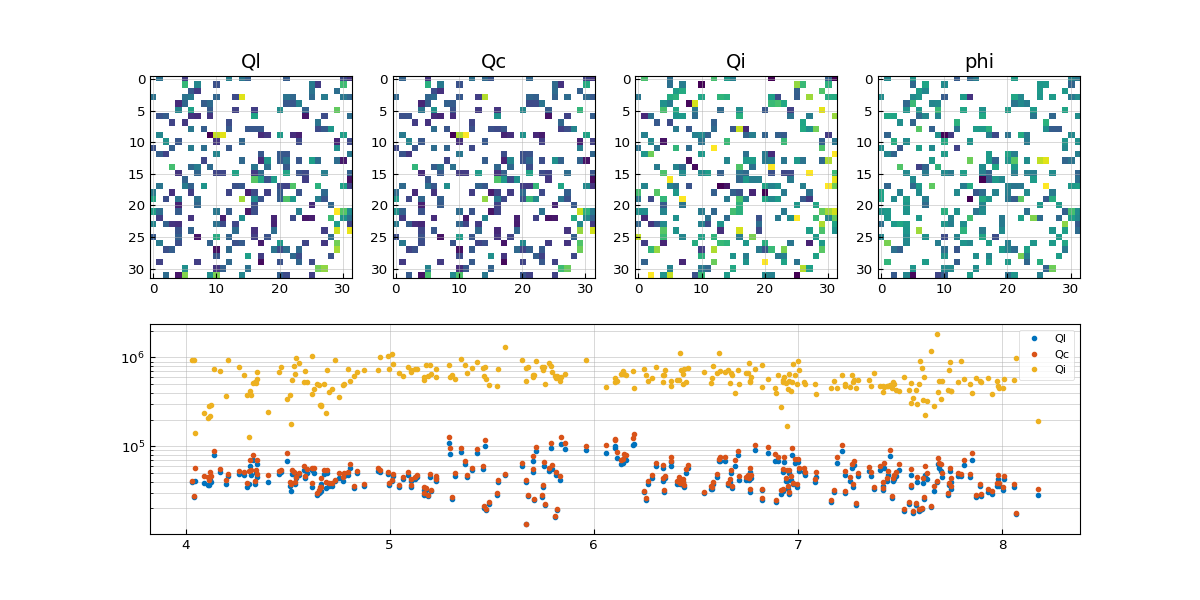

In [ ]:
fig, axes = plt.subplot_mosaic('abcd;eeee', figsize=(12,6))
Ql = np.asarray(df_sorted['Ql'])
Qi = np.asarray(df_sorted['Qi'])
Qc = np.asarray(df_sorted['Qc'])
phi = np.asarray(df_sorted['phi'])
ax = axes['a']
ax.imshow(Ql[kid_id_board])
ax.set_title('Ql')
ax = axes['b']
ax.imshow(Qc[kid_id_board])
ax.set_title('Qc')
ax = axes['c']
ax.imshow(Qi[kid_id_board], vmin=2e5, vmax=1e6)
ax.set_title('Qi')
ax = axes['d']
ax.imshow(phi[kid_id_board])
ax.set_title('phi')
ax = axes['e']
ax.plot(f0_mapped, Ql, '.', label='Ql')
ax.plot(f0_mapped, Qc, '.', label='Qc')
ax.plot(f0_mapped, Qi, '.', label='Qi')
ax.set_yscale('log')
ax.legend()


In [ ]:
keys = ['Ql', 'Qi', 'Qc', 'phi']
for key in keys:
    master['measured'][key] = np.asarray(df_sorted[key])

In [ ]:
# with open('LT402chip6_master.pkl', 'wb') as f:
#     pickle.dump(master, f)